# CellOracle GRN Inference: Norman 2019 (K562)

**Purpose:** Build K562-specific GRN → extract M matrix for scGPT attention bias (Stage 2).

**Features:**
- Timestamped output dir `celloracle_grn_YYYYMMDD_HHMMSS/`
- Interactive selection of previous run to resume
- Per-stage checkpoints — survives kernel restarts / disconnects
- Log file in output dir

**Design notes:**
- K562 is a single cell type → uses `GRN_unit="whole"`
- CellOracle used as **GRN source** (M matrix), not perturbation benchmark

In [1]:
#1.1 Environment setup — must run first
import os
os.environ["PATH"] = "/conda_envs/celloracle_env/bin:" + os.environ["PATH"]

import importlib
import pybedtools
import pybedtools.bedtool
importlib.reload(pybedtools.bedtool)
importlib.reload(pybedtools)

# Verify bedtools works
a = pybedtools.example_bedtool('a.bed')
b = pybedtools.example_bedtool('b.bed')
result = a.intersect(b)
assert len(result) > 0, "bedtools intersect failed"
print(f"bedtools OK ({len(result)} intervals)")

bedtools OK (3 intervals)


In [2]:
#1.2 Configuration — edit paths here
BED_PATH    = "../../data/ATAC_Seq/K562/K562_ATAC_peaks.bed"
NORMAN_H5AD = "../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad"
GENOMES_DIR = "../../data/genomes"
REF_GENOME  = "hg38"

N_TOP_GENES    = 3000
MAX_CELLS      = 30000
MOTIF_SCORE_TH = 10
MOTIF_FPR      = 0.02
MOTIF_NCPUS    = 8
GRN_ALPHA      = 10
LINK_P_THRESH  = 0.001
LINK_TOP_EDGES = 2000

In [3]:
#1.3 Output dir — resume previous or create new
import glob
import sys
import logging
from datetime import datetime

BASE_PREFIX = "celloracle_grn_"
previous_dirs = sorted([d.rstrip("/") for d in glob.glob(f"{BASE_PREFIX}*/") if os.path.isdir(d)])

RESUME = False
OUTPUT_DIR = None

if previous_dirs:
    print("Previous runs found:")
    for i, d in enumerate(previous_dirs):
        # List checkpoints in each dir
        files = os.listdir(d)
        ckpts = [f for f in files if not f.endswith('.log')]
        print(f"  [{i}] {d}  ({len(ckpts)} checkpoints: {', '.join(sorted(ckpts))})")
    print(f"  [N] Start new run")
    print()
    # ---- SET YOUR CHOICE HERE ----
    # Change this to the index of the run you want to resume, or 'N' for new
    CHOICE = 0  # <-- edit: integer index or 'N'
    # ------------------------------
    if isinstance(CHOICE, int) and 0 <= CHOICE < len(previous_dirs):
        OUTPUT_DIR = previous_dirs[CHOICE]
        RESUME = True
        print(f">>> Resuming: {OUTPUT_DIR}")
    else:
        print(">>> Starting new run")

if OUTPUT_DIR is None:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    OUTPUT_DIR = f"{BASE_PREFIX}{ts}"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    print(f">>> New run: {OUTPUT_DIR}")

print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"RESUME = {RESUME}")

>>> New run: celloracle_grn_20260305_221104
OUTPUT_DIR = celloracle_grn_20260305_221104
RESUME = False


In [4]:
#1.4 Logger setup
log_path = os.path.join(OUTPUT_DIR, "celloracle_grn.log")

logger = logging.getLogger("celloracle_grn")
logger.handlers.clear()
logger.setLevel(logging.INFO)

fmt = logging.Formatter("%(asctime)s [%(levelname)s] %(message)s", datefmt="%Y-%m-%d %H:%M:%S")

fh = logging.FileHandler(log_path, mode="a")
fh.setFormatter(fmt)
logger.addHandler(fh)

sh = logging.StreamHandler(sys.stdout)
sh.setFormatter(fmt)
logger.addHandler(sh)

logger.info(f"=== Session start (RESUME={RESUME}) ===")
logger.info(f"Output dir: {OUTPUT_DIR}")

2026-03-05 22:11:04 [INFO] === Session start (RESUME=False) ===
2026-03-05 22:11:04 [INFO] Output dir: celloracle_grn_20260305_221104


In [5]:
#1.5 Checkpoint helpers
def ckpt_path(name):
    return os.path.join(OUTPUT_DIR, name)

def ckpt_exists(name):
    p = ckpt_path(name)
    exists = os.path.exists(p)
    if exists:
        logger.info(f"Checkpoint found: {name}")
    return exists

In [6]:
#1.6 Verify inputs exist
for p, label in [
    (BED_PATH, "BED"),
    (NORMAN_H5AD, "Norman h5ad"),
    (f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa", "Genome FASTA"),
]:
    assert os.path.exists(p), f"Missing {label}: {p}"
    logger.info(f"Input OK: {label} -> {p}")

2026-03-05 22:11:04 [INFO] Input OK: BED -> ../../data/ATAC_Seq/K562/K562_ATAC_peaks.bed
2026-03-05 22:11:04 [INFO] Input OK: Norman h5ad -> ../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad
2026-03-05 22:11:04 [INFO] Input OK: Genome FASTA -> ../../data/genomes/hg38/hg38.fa


In [7]:
#1.7 Imports
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scanpy as sc
import matplotlib.pyplot as plt
import celloracle as co
from celloracle import motif_analysis as ma

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams['savefig.dpi'] = 300

logger.info(f"CellOracle version: {co.__version__}")

/conda_envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


2026-03-05 22:11:15 [INFO] CellOracle version: 0.20.0


2026-03-05 22:11:15,935 - INFO - CellOracle version: 0.20.0


## 2. Bulk ATAC-seq → TSS Annotation

In [8]:
#2.1 TSS annotation from BED peaks
CKPT_TSS = "K562_processed_peak_file.csv"

if ckpt_exists(CKPT_TSS):
    tss_annotated_df = pd.read_csv(ckpt_path(CKPT_TSS))
    logger.info(f"Loaded TSS: {tss_annotated_df.shape[0]} peak-gene pairs")
else:
    logger.info("BED -> TSS annotation")
    bed = ma.read_bed(BED_PATH)
    logger.info(f"Peaks loaded: {bed.shape[0]}")

    peaks = ma.process_bed_file.df_to_list_peakstr(bed)
    logger.info(f"Total peaks: {len(peaks)}")

    # Genome symlinks for gimmemotifs
    default_genome_dir = os.path.expanduser(f"~/.local/share/genomes/{REF_GENOME}")
    os.makedirs(default_genome_dir, exist_ok=True)
    src_fa  = os.path.abspath(f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa")
    src_fai = os.path.abspath(f"{GENOMES_DIR}/{REF_GENOME}/{REF_GENOME}.fa.fai")
    for src in [src_fa, src_fai]:
        dst = os.path.join(default_genome_dir, os.path.basename(src))
        if not os.path.exists(dst):
            os.symlink(src, dst)
            logger.info(f"Symlinked: {dst}")
    sizes_file = os.path.join(default_genome_dir, f"{REF_GENOME}.fa.sizes")
    if not os.path.exists(sizes_file):
        fai = pd.read_csv(src_fai, sep='\t', header=None, usecols=[0,1], names=['chrom','size'])
        fai.to_csv(sizes_file, sep='\t', header=False, index=False)

    tss_annotated = ma.get_tss_info(peak_str_list=peaks, ref_genome=REF_GENOME)
    logger.info(f"TSS-annotated peaks: {tss_annotated.shape[0]}")

    peak_id_tss = ma.process_bed_file.df_to_list_peakstr(tss_annotated)
    tss_annotated_df = pd.DataFrame({
        "peak_id": peak_id_tss,
        "gene_short_name": tss_annotated.gene_short_name.values
    }).reset_index(drop=True)

    tss_annotated_df.to_csv(ckpt_path(CKPT_TSS), index=False)
    logger.info(f"Saved: {tss_annotated_df.shape[0]} pairs, {tss_annotated_df['gene_short_name'].nunique()} genes")

2026-03-05 22:11:15 [INFO] BED -> TSS annotation


2026-03-05 22:11:15,945 - INFO - BED -> TSS annotation


2026-03-05 22:11:16 [INFO] Peaks loaded: 181340


2026-03-05 22:11:16,164 - INFO - Peaks loaded: 181340


2026-03-05 22:11:16 [INFO] Total peaks: 181340


2026-03-05 22:11:16,318 - INFO - Total peaks: 181340


que bed peaks: 181340
tss peaks in que: 67318
2026-03-05 22:11:17 [INFO] TSS-annotated peaks: 67318


2026-03-05 22:11:17,161 - INFO - TSS-annotated peaks: 67318


2026-03-05 22:11:17 [INFO] Saved: 67318 pairs, 15344 genes


2026-03-05 22:11:17,283 - INFO - Saved: 67318 pairs, 15344 genes


## 3. TF Motif Scan → Base GRN

In [9]:
#3.1 Motif scan (rate-limiting: ~30-60 min first time)
CKPT_TFINFO = "K562_TFinfo.celloracle.tfinfo"
CKPT_BASE_GRN = "K562_base_GRN.parquet"

if ckpt_exists(CKPT_BASE_GRN):
    base_GRN_df = pd.read_parquet(ckpt_path(CKPT_BASE_GRN))
    logger.info(f"Loaded base GRN: {base_GRN_df.shape[0]} peaks x {base_GRN_df.shape[1]-2} TFs")
else:
    if ckpt_exists(CKPT_TFINFO):
        logger.info("Loading motif scan checkpoint")
        tfi = ma.load_TFinfo_from_parquets(ckpt_path(CKPT_TFINFO))
    else:
        logger.info("Motif scan starting (may take 30-60 min)")
        tfi = ma.TFinfo(
            peak_data_frame=tss_annotated_df,
            ref_genome=REF_GENOME,
            genomes_dir=GENOMES_DIR
        )
        tfi.scan(fpr=MOTIF_FPR, motifs=None, verbose=True, n_cpus=MOTIF_NCPUS)
        tfi.save_as_parquet(ckpt_path(CKPT_TFINFO))
        logger.info("Motif scan checkpoint saved")

    tfi.reset_filtering()
    tfi.filter_motifs_by_score(threshold=MOTIF_SCORE_TH)
    tfi.make_TFinfo_dataframe_and_dictionary(verbose=True)

    base_GRN_df = tfi.to_dataframe()
    base_GRN_df.to_parquet(ckpt_path(CKPT_BASE_GRN))
    logger.info(f"Base GRN saved: {base_GRN_df.shape[0]} peaks x {base_GRN_df.shape[1]-2} TFs")

2026-03-05 22:11:17 [INFO] Motif scan starting (may take 30-60 min)


2026-03-05 22:11:17,291 - INFO - Motif scan starting (may take 30-60 min)


No motif data entered. Loading default motifs for your species ...
 Default motif for vertebrate: gimme.vertebrate.v5.0. 
 For more information, please see https://gimmemotifs.readthedocs.io/en/master/overview.html 

Initiating scanner... 



2026-03-05 22:11:22,280 - DEBUG - using background: genome hg38 with size 200


Calculating FPR-based threshold. This step may take substantial time when you load a new ref-genome. It will be done quicker on the second time. 

Motif scan started .. It may take long time.



...

2. Converting results into dictionaries.


  0%|          | 0/15344 [00:00<?, ?it/s]

  0%|          | 0/1093 [00:00<?, ?it/s]

2026-03-05 22:18:33 [INFO] Base GRN saved: 17790 peaks x 1093 TFs


2026-03-05 22:18:33,310 - INFO - Base GRN saved: 17790 peaks x 1093 TFs


## 4. Prepare Norman 2019 scRNA-seq

K562 = single cell type. Pure ctrl cells, single cluster, UMAP embedding.

In [10]:
#4.1 Preprocess ctrl cells
CKPT_ADATA = "K562_ctrl_preprocessed.h5ad"

if ckpt_exists(CKPT_ADATA):
    adata_co = sc.read_h5ad(ckpt_path(CKPT_ADATA))
    logger.info(f"Loaded adata: {adata_co.shape}")
else:
    logger.info("Preprocessing Norman 2019 ctrl cells")
    adata = sc.read_h5ad(NORMAN_H5AD)
    logger.info(f"Full: {adata.shape}, conditions: {adata.obs['condition'].nunique()}")

    # Pure ctrl only
    adata_ctrl = adata[adata.obs['condition'] == 'ctrl'].copy()
    logger.info(f"Pure ctrl cells: {adata_ctrl.shape[0]}")

    if adata_ctrl.shape[0] < 1000:
        logger.warning("<1000 pure ctrl, expanding to gene+ctrl singles")
        ctrl_labels = [c for c in adata.obs['condition'].unique()
                       if c == 'ctrl' or '+ctrl' in c or 'ctrl+' in c]
        adata_ctrl = adata[adata.obs['condition'].isin(ctrl_labels)].copy()
        logger.info(f"Expanded ctrl: {adata_ctrl.shape[0]}")

    logger.info(f"X max={adata_ctrl.X.max():.1f}, dtype={adata_ctrl.X.dtype}")

    adata_co = adata_ctrl.copy()
    adata_co.layers['raw_count'] = adata_co.X.copy()

    sc.pp.normalize_total(adata_co, target_sum=1e4)
    sc.pp.log1p(adata_co)
    sc.pp.highly_variable_genes(adata_co, n_top_genes=N_TOP_GENES)
    adata_co = adata_co[:, adata_co.var['highly_variable']].copy()
    logger.info(f"After HVG: {adata_co.shape}")

    sc.pp.scale(adata_co, max_value=10)
    sc.tl.pca(adata_co, svd_solver='arpack', n_comps=50)
    sc.pp.neighbors(adata_co, n_neighbors=15, n_pcs=30)

    # Single cluster (K562 = one cell type, no trajectory)
    adata_co.obs['cluster'] = pd.Categorical(['K562'] * adata_co.shape[0])
    adata_co.uns['cluster_colors'] = ['#1f77b4']
    logger.info("Single cluster 'K562' assigned")

    if adata_co.shape[0] > MAX_CELLS:
        sc.pp.subsample(adata_co, n_obs=MAX_CELLS, random_state=42)
        logger.info(f"Downsampled to {adata_co.shape[0]}")

    # UMAP (Oracle requires embedding; only for simulation viz, not GRN)
    sc.tl.umap(adata_co)
    logger.info(f"UMAP done. obsm keys: {list(adata_co.obsm.keys())}")

    adata_co.write_h5ad(ckpt_path(CKPT_ADATA))
    logger.info(f"Saved adata: {adata_co.shape}")

2026-03-05 22:18:33 [INFO] Preprocessing Norman 2019 ctrl cells


2026-03-05 22:18:33,320 - INFO - Preprocessing Norman 2019 ctrl cells


2026-03-05 22:18:36 [INFO] Full: (89357, 5045), conditions: 277


2026-03-05 22:18:36,946 - INFO - Full: (89357, 5045), conditions: 277


2026-03-05 22:18:37 [INFO] Pure ctrl cells: 7353


...

2026-03-05 22:19:00,888 - INFO - Single cluster 'K562' assigned


2026-03-05 22:19:18 [INFO] UMAP done. obsm keys: ['X_pca', 'X_umap']


2026-03-05 22:19:18,334 - INFO - UMAP done. obsm keys: ['X_pca', 'X_umap']


2026-03-05 22:19:20 [INFO] Saved adata: (7353, 3000)


2026-03-05 22:19:20,130 - INFO - Saved adata: (7353, 3000)


## 5. CellOracle Oracle Object + KNN Imputation

In [11]:
#5.1 Build Oracle (or load checkpoint)
CKPT_ORACLE = "K562_norman.celloracle.oracle"

if ckpt_exists(CKPT_ORACLE):
    oracle = co.load_hdf5(ckpt_path(CKPT_ORACLE))
    logger.info("Loaded Oracle checkpoint")
else:
    logger.info("Building Oracle object")

    # Gene name overlap diagnostic
    grn_genes = set(base_GRN_df['gene_short_name'])
    adata_genes = set(adata_co.var_names)
    overlap = grn_genes & adata_genes
    logger.info(f"Gene overlap: GRN={len(grn_genes)}, adata={len(adata_genes)}, overlap={len(overlap)}")

    if len(overlap) == 0:
        logger.warning("Zero overlap! Scanning adata.var columns...")
        for col in adata_co.var.columns:
            n = len(grn_genes & set(adata_co.var[col].astype(str)))
            if n > 0:
                logger.info(f"  var['{col}']: {n} matches")
        for col in ['gene_name', 'gene_short_name', 'symbol', 'gene_symbols']:
            if col in adata_co.var.columns:
                n = len(grn_genes & set(adata_co.var[col].astype(str)))
                if n > 100:
                    logger.info(f"Remapping var_names -> var['{col}'] ({n} matches)")
                    adata_co.var_names = adata_co.var[col].astype(str).values
                    adata_co.var_names_make_unique()
                    break

    oracle = co.Oracle()
    adata_co.X = adata_co.layers['raw_count'].copy()

    embedding_name = "X_umap"
    if embedding_name not in adata_co.obsm:
        embedding_name = list(adata_co.obsm.keys())[0]
        logger.warning(f"X_umap missing, using {embedding_name}")

    oracle.import_anndata_as_raw_count(
        adata=adata_co,
        cluster_column_name="cluster",
        embedding_name=embedding_name
    )
    logger.info("Anndata imported")

    oracle.import_TF_data(TF_info_matrix=base_GRN_df)
    logger.info("Base GRN imported")

    # Verify overlap post-import
    n_reg = oracle.adata.var.get('isin_TFdict_regulators', pd.Series(dtype=bool)).sum()
    n_tgt = oracle.adata.var.get('isin_TFdict_targets', pd.Series(dtype=bool)).sum()
    logger.info(f"Overlap post-import: regulators={n_reg}, targets={n_tgt}")
    if n_reg == 0 or n_tgt == 0:
        logger.error("FATAL: No gene overlap. Fix gene names.")
        raise ValueError("No overlap between base GRN and adata var_names.")

2026-03-05 22:19:20 [INFO] Building Oracle object


2026-03-05 22:19:20,141 - INFO - Building Oracle object


2026-03-05 22:19:20 [INFO] Gene overlap: GRN=15344, adata=3000, overlap=0


2026-03-05 22:19:20,146 - INFO - Gene overlap: GRN=15344, adata=3000, overlap=0


2026-03-05 22:19:20 [WARNING] Zero overlap! Scanning adata.var columns...


...

2026-03-05 22:19:21,232 - INFO - Anndata imported


2026-03-05 22:19:25 [INFO] Base GRN imported


2026-03-05 22:19:25,195 - INFO - Base GRN imported


2026-03-05 22:19:25 [INFO] Overlap post-import: regulators=131, targets=1513


2026-03-05 22:19:25,196 - INFO - Overlap post-import: regulators=131, targets=1513


In [12]:
#5.2 PCA + KNN imputation (continued from 5.1 if no checkpoint)
if not ckpt_exists(CKPT_ORACLE):
    oracle.perform_PCA()
    n_comps = min(
        np.where(np.diff(np.diff(np.cumsum(oracle.pca.explained_variance_ratio_)) > 0.002))[0][0],
        50
    )
    logger.info(f"PCA: {n_comps} components")

    n_cell = oracle.adata.shape[0]
    k = max(int(0.025 * n_cell), 30)
    logger.info(f"KNN imputation: n_cell={n_cell}, k={k}")
    oracle.knn_imputation(
        n_pca_dims=n_comps, k=k, balanced=True,
        b_sight=k*8, b_maxl=k*4, n_jobs=4
    )
    logger.info("KNN imputation done")

    oracle.to_hdf5(ckpt_path(CKPT_ORACLE))
    logger.info("Oracle checkpoint saved")

2026-03-05 22:20:25 [INFO] PCA: 50 components


2026-03-05 22:20:25,923 - INFO - PCA: 50 components


2026-03-05 22:20:25 [INFO] KNN imputation: n_cell=7353, k=183


2026-03-05 22:20:25,926 - INFO - KNN imputation: n_cell=7353, k=183


2026-03-05 22:20:31 [INFO] KNN imputation done


2026-03-05 22:20:31,486 - INFO - KNN imputation done


2026-03-05 22:20:51 [INFO] Oracle checkpoint saved


2026-03-05 22:20:51,553 - INFO - Oracle checkpoint saved


## 6. GRN Inference

In [15]:
#6.1 GRN inference with GRN_unit='whole' (single cell type)
CKPT_LINKS = "K562_norman.celloracle.links"

if ckpt_exists(CKPT_LINKS):
    links = co.load_hdf5(ckpt_path(CKPT_LINKS))
    logger.info("Loaded Links checkpoint")
else:
    logger.info("GRN inference (GRN_unit='whole')")
    links = oracle.get_links(
        cluster_name_for_GRN_unit= "cluster", #"whole",
        alpha=GRN_ALPHA,
        verbose_level=10
    )
    logger.info("GRN inference done")

    links.filter_links(p=LINK_P_THRESH, weight="coef_abs", threshold_number=LINK_TOP_EDGES)
    links.to_hdf5(ckpt_path(CKPT_LINKS))
    logger.info("Links checkpoint saved")

2026-03-05 22:22:22 [INFO] GRN inference (GRN_unit='whole')


2026-03-05 22:22:22,651 - INFO - GRN inference (GRN_unit='whole')


  0%|          | 0/1 [00:00<?, ?it/s]

Inferring GRN for K562...


  0%|          | 0/1513 [00:00<?, ?it/s]

2026-03-05 22:24:56 [INFO] GRN inference done


2026-03-05 22:24:56,510 - INFO - GRN inference done


2026-03-05 22:24:56 [INFO] Links checkpoint saved


2026-03-05 22:24:56,831 - INFO - Links checkpoint saved


## 7. Extract M Matrix

In [16]:
#7.1 Build and save M matrix
CKPT_M = "K562_GRN_M_matrix.csv"

if ckpt_exists(CKPT_M):
    M_matrix = pd.read_csv(ckpt_path(CKPT_M), index_col=0)
    logger.info(f"Loaded M matrix: {M_matrix.shape}")
else:
    logger.info("Extracting M matrix")

    all_edges = []
    for cname, grn in links.links_dict.items():
        g = grn.copy()
        g['cluster'] = cname
        all_edges.append(g)
    all_edges_df = pd.concat(all_edges, ignore_index=True)
    logger.info(f"Total edges: {all_edges_df.shape[0]}")

    mean_edges = all_edges_df.groupby(['source','target']).agg(
        coef_mean=('coef_mean','mean'),
        coef_abs_mean=('coef_abs','mean'),
        p_min=('p','min')
    ).reset_index()
    logger.info(f"Unique edges: {mean_edges.shape[0]}, TFs: {mean_edges['source'].nunique()}, Targets: {mean_edges['target'].nunique()}")

    sig_edges = mean_edges[mean_edges['p_min'] < LINK_P_THRESH].copy()
    logger.info(f"Significant edges (p<{LINK_P_THRESH}): {sig_edges.shape[0]}")

    M_matrix = sig_edges.pivot_table(
        index='target', columns='source',
        values='coef_mean', fill_value=0.0
    )
    logger.info(f"M shape: {M_matrix.shape}, non-zero: {(M_matrix!=0).sum().sum()}, sparsity: {1-(M_matrix!=0).sum().sum()/M_matrix.size:.4f}")

    M_matrix.to_csv(ckpt_path(CKPT_M))
    np.save(ckpt_path("K562_GRN_M_matrix.npy"), M_matrix.values)
    pd.Series(M_matrix.index, name='target_gene').to_csv(
        ckpt_path("K562_GRN_M_target_genes.csv"), index=False)
    pd.Series(M_matrix.columns, name='source_TF').to_csv(
        ckpt_path("K562_GRN_M_source_TFs.csv"), index=False)
    mean_edges.to_csv(ckpt_path("K562_GRN_mean_edges.csv"), index=False)
    logger.info("All M matrix files saved")

2026-03-05 22:24:56 [INFO] Extracting M matrix


2026-03-05 22:24:56,859 - INFO - Extracting M matrix


2026-03-05 22:24:56 [INFO] Total edges: 48783


2026-03-05 22:24:56,863 - INFO - Total edges: 48783


2026-03-05 22:24:56 [INFO] Unique edges: 48783, TFs: 131, Targets: 1513


...

2026-03-05 22:24:56,894 - INFO - Significant edges (p<0.001): 36141


2026-03-05 22:24:56 [INFO] M shape: (1513, 131), non-zero: 36141, sparsity: 0.8177


2026-03-05 22:24:56,933 - INFO - M shape: (1513, 131), non-zero: 36141, sparsity: 0.8177


2026-03-05 22:24:57 [INFO] All M matrix files saved


2026-03-05 22:24:57,184 - INFO - All M matrix files saved


## 8. Sanity Checks

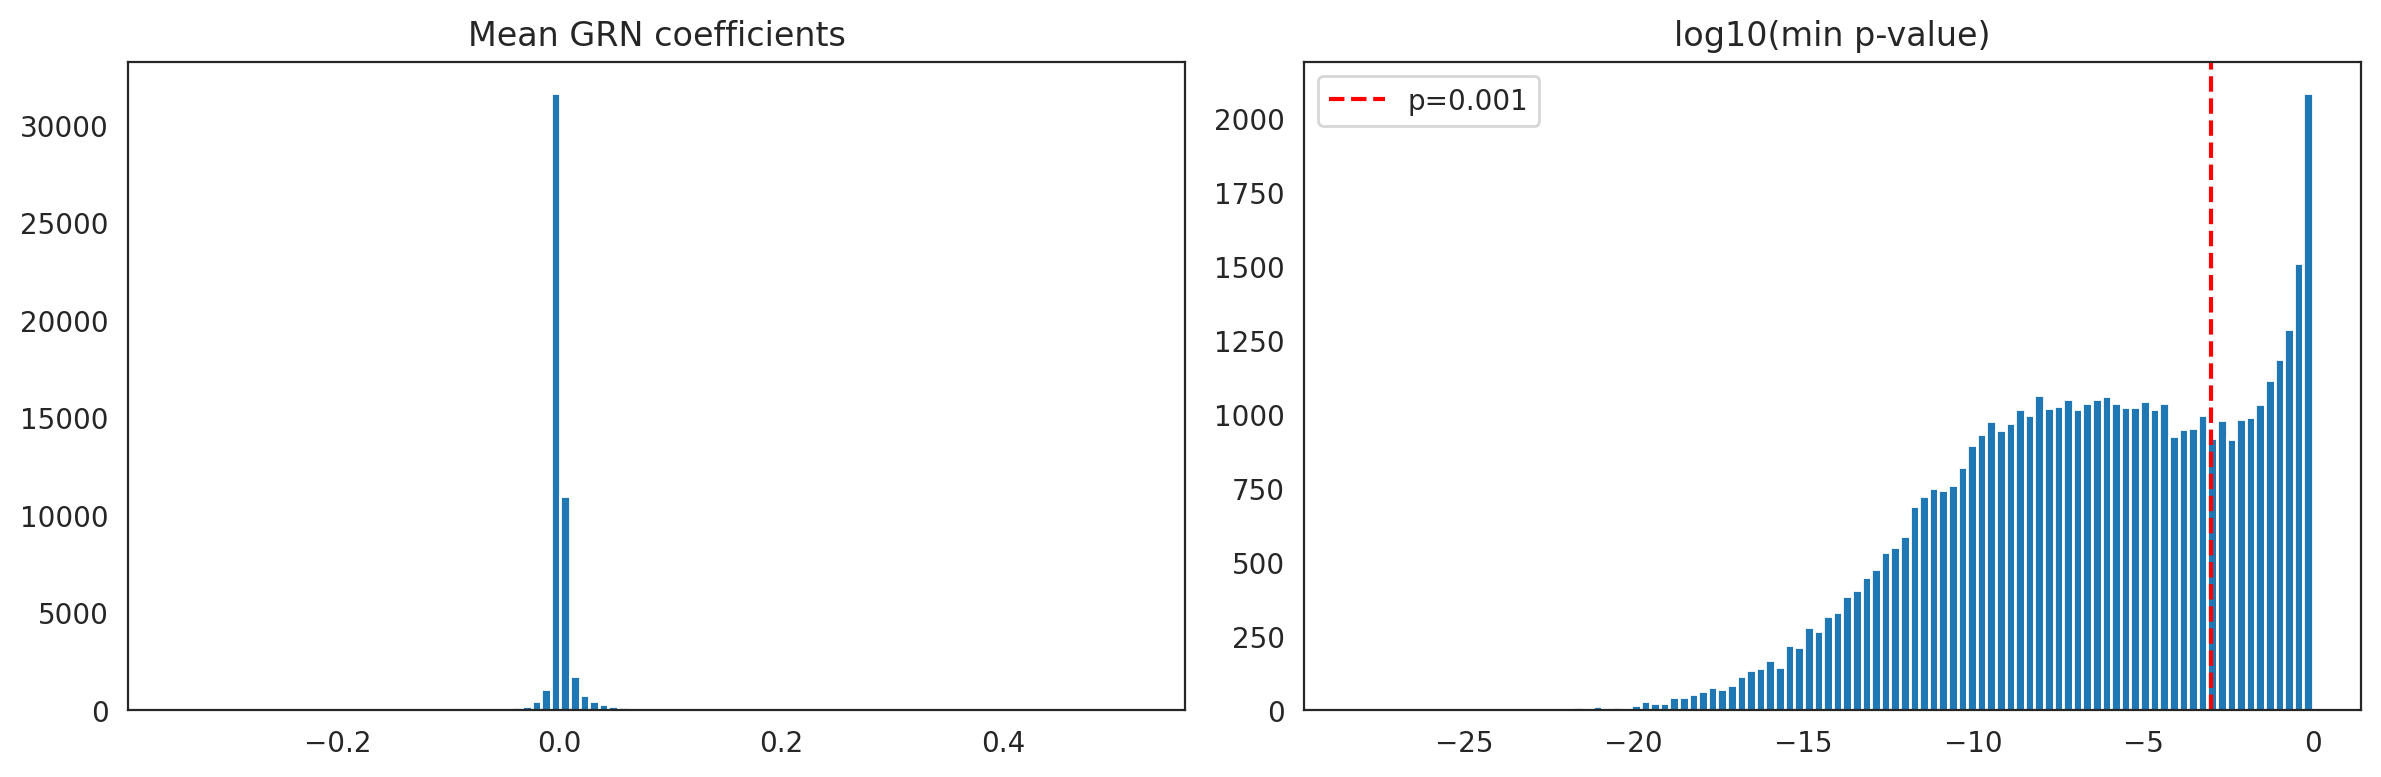

2026-03-05 22:24:58 [INFO] Saved sanity_coef_pval.png


2026-03-05 22:24:58,247 - INFO - Saved sanity_coef_pval.png


In [17]:
#8.1 Coefficient and p-value distributions
me = pd.read_csv(ckpt_path("K562_GRN_mean_edges.csv"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(me['coef_mean'], bins=100)
axes[0].set_title('Mean GRN coefficients')
axes[1].hist(np.log10(me['p_min']+1e-300), bins=100)
axes[1].axvline(np.log10(LINK_P_THRESH), c='r', ls='--', label=f'p={LINK_P_THRESH}')
axes[1].set_title('log10(min p-value)')
axes[1].legend()
plt.tight_layout()
plt.savefig(ckpt_path("sanity_coef_pval.png"), dpi=150, bbox_inches='tight')
plt.show()
logger.info("Saved sanity_coef_pval.png")

In [18]:
#8.2 Top TFs by out-degree
sig = me[me['p_min'] < LINK_P_THRESH]
tf_degree = sig.groupby('source')['target'].nunique().sort_values(ascending=False)
logger.info(f"Top 20 TFs:\n{tf_degree.head(20).to_string()}")
print(tf_degree.head(20))

2026-03-05 22:24:58 [INFO] Top 20 TFs:
source
TFAP2A     945
SP6        928
EGR1       916
HEY1       910
IRF1       904
PRDM1      888
KLF2       879
ATF3       864
BHLHE40    862
KLF7       850
KLF6       848
MEF2C      843
ETS1       830
FOXA1      827
MYC        807
CHD2       799
ZEB1       774
ZNF467     768
FOS        765
KLF4       735


2026-03-05 22:24:58,354 - INFO - Top 20 TFs:
source
TFAP2A     945
SP6        928
EGR1       916
HEY1       910
IRF1       904
PRDM1      888
KLF2       879
ATF3       864
BHLHE40    862
KLF7       850
KLF6       848
MEF2C      843
ETS1       830
FOXA1      827
MYC        807
CHD2       799
ZEB1       774
ZNF467     768
FOS        765
KLF4       735


source
TFAP2A     945
SP6        928
EGR1       916
HEY1       910
IRF1       904
PRDM1      888
KLF2       879
ATF3       864
BHLHE40    862
KLF7       850
KLF6       848
MEF2C      843
ETS1       830
FOXA1      827
MYC        807
CHD2       799
ZEB1       774
ZNF467     768
FOS        765
KLF4       735
Name: target, dtype: int64


In [19]:
#8.3 Overlap with Norman perturbed genes
adata_full = sc.read_h5ad(NORMAN_H5AD)
perturbed_genes = set()
for c in adata_full.obs['condition'].unique():
    if c != 'ctrl':
        for g in c.split('+'):
            if g.strip() != 'ctrl':
                perturbed_genes.add(g.strip())

grn_tfs = set(M_matrix.columns)
overlap = perturbed_genes & grn_tfs
missing = perturbed_genes - grn_tfs
logger.info(f"Perturbed: {len(perturbed_genes)}, GRN TFs: {len(grn_tfs)}, Overlap: {len(overlap)} ({len(overlap)/len(perturbed_genes)*100:.1f}%)")
if missing:
    logger.info(f"Missing ({len(missing)}): {missing}")
    print(f"Missing ({len(missing)}): {missing}")

2026-03-05 22:25:02 [INFO] Perturbed: 102, GRN TFs: 131, Overlap: 31 (30.4%)


2026-03-05 22:25:02,162 - INFO - Perturbed: 102, GRN TFs: 131, Overlap: 31 (30.4%)


2026-03-05 22:25:02 [INFO] Missing (71): {'GLB1L2', 'CDKN1A', 'ATL1', 'HOXA13', 'PTPN12', 'HNF4A', 'PTPN9', 'C3orf72', 'CITED1', 'BCORL1', 'IGDCC3', 'PLK4', 'KIF18B', 'FOXF1', 'SAMD1', 'MAP2K3', 'MAP7D1', 'NCL', 'CBFA2T3', 'ELMSAN1', 'RUNX1T1', 'MAP4K3', 'UBASH3A', 'ZC3HAV1', 'CSRNP1', 'BCL2L11', 'UBASH3B', 'NIT1', 'CDKN1C', 'MAP2K6', 'SLC4A1', 'MAP4K5', 'BAK1', 'HK2', 'MAML2', 'DUSP9', 'TMSB4X', 'C19orf26', 'SLC38A2', 'CNN1', 'ZNF318', 'CNNM4', 'COL1A1', 'ZBTB10', 'LYL1', 'CDKN1B', 'TGFBR2', 'MAPK1', 'ZBTB25', 'SGK1', 'BPGM', 'KLF1', 'PRTG', 'SLC6A9', 'CELF2', 'KIF2C', 'MIDN', 'ARRDC3', 'CBL', 'S1PR2', 'KMT2A', 'STIL', 'CKS1B', 'PTPN1', 'COL2A1', 'ARID1A', 'SET', 'HOXB9', 'PTPN13', 'CLDN6', 'TSC22D1'}


2026-03-05 22:25:02,163 - INFO - Missing (71): {'GLB1L2', 'CDKN1A', 'ATL1', 'HOXA13', 'PTPN12', 'HNF4A', 'PTPN9', 'C3orf72', 'CITED1', 'BCORL1', 'IGDCC3', 'PLK4', 'KIF18B', 'FOXF1', 'SAMD1', 'MAP2K3', 'MAP7D1', 'NCL', 'CBFA2T3', 'ELMSAN1', 'RUNX1T1', 'MAP4K3', 'UBASH3A', 'ZC3HAV1', 'CSRNP1', 'BCL2L11', 'UBASH3B', 'NIT1', 'CDKN1C', 'MAP2K6', 'SLC4A1', 'MAP4K5', 'BAK1', 'HK2', 'MAML2', 'DUSP9', 'TMSB4X', 'C19orf26', 'SLC38A2', 'CNN1', 'ZNF318', 'CNNM4', 'COL1A1', 'ZBTB10', 'LYL1', 'CDKN1B', 'TGFBR2', 'MAPK1', 'ZBTB25', 'SGK1', 'BPGM', 'KLF1', 'PRTG', 'SLC6A9', 'CELF2', 'KIF2C', 'MIDN', 'ARRDC3', 'CBL', 'S1PR2', 'KMT2A', 'STIL', 'CKS1B', 'PTPN1', 'COL2A1', 'ARID1A', 'SET', 'HOXB9', 'PTPN13', 'CLDN6', 'TSC22D1'}


Missing (71): {'GLB1L2', 'CDKN1A', 'ATL1', 'HOXA13', 'PTPN12', 'HNF4A', 'PTPN9', 'C3orf72', 'CITED1', 'BCORL1', 'IGDCC3', 'PLK4', 'KIF18B', 'FOXF1', 'SAMD1', 'MAP2K3', 'MAP7D1', 'NCL', 'CBFA2T3', 'ELMSAN1', 'RUNX1T1', 'MAP4K3', 'UBASH3A', 'ZC3HAV1', 'CSRNP1', 'BCL2L11', 'UBASH3B', 'NIT1', 'CDKN1C', 'MAP2K6', 'SLC4A1', 'MAP4K5', 'BAK1', 'HK2', 'MAML2', 'DUSP9', 'TMSB4X', 'C19orf26', 'SLC38A2', 'CNN1', 'ZNF318', 'CNNM4', 'COL1A1', 'ZBTB10', 'LYL1', 'CDKN1B', 'TGFBR2', 'MAPK1', 'ZBTB25', 'SGK1', 'BPGM', 'KLF1', 'PRTG', 'SLC6A9', 'CELF2', 'KIF2C', 'MIDN', 'ARRDC3', 'CBL', 'S1PR2', 'KMT2A', 'STIL', 'CKS1B', 'PTPN1', 'COL2A1', 'ARID1A', 'SET', 'HOXB9', 'PTPN13', 'CLDN6', 'TSC22D1'}


In [20]:
#8.4 Final output listing
logger.info("=== Final outputs ===")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1e6
    logger.info(f"  {f} ({size_mb:.1f} MB)")
logger.info("=== Pipeline complete ===")

2026-03-05 22:25:02 [INFO] === Final outputs ===


2026-03-05 22:25:02,168 - INFO - === Final outputs ===


2026-03-05 22:25:02 [INFO]   K562_GRN_M_matrix.csv (1.1 MB)


2026-03-05 22:25:02,170 - INFO -   K562_GRN_M_matrix.csv (1.1 MB)


2026-03-05 22:25:02 [INFO]   K562_GRN_M_matrix.npy (0.8 MB)


...

2026-03-05 22:25:02,180 - INFO -   celloracle_grn.log (0.0 MB)


2026-03-05 22:25:02 [INFO]   sanity_coef_pval.png (0.0 MB)


2026-03-05 22:25:02,181 - INFO -   sanity_coef_pval.png (0.0 MB)


2026-03-05 22:25:02 [INFO] === Pipeline complete ===


2026-03-05 22:25:02,182 - INFO - === Pipeline complete ===


## Output Summary

| File | Purpose |
|---|---|
| `K562_GRN_M_matrix.npy` | **M for Stage 2**: `attn_scores += alpha * M_grn` |
| `K562_GRN_M_matrix.csv` | Same, readable |
| `K562_GRN_M_target_genes.csv` | Row index |
| `K562_GRN_M_source_TFs.csv` | Column index |
| `K562_GRN_mean_edges.csv` | Full edge list |
| `K562_base_GRN.parquet` | Base GRN |
| `K562_TFinfo.celloracle.tfinfo` | Motif scan checkpoint |
| `K562_norman.celloracle.oracle` | Oracle checkpoint |
| `K562_norman.celloracle.links` | GRN links |
| `celloracle_grn.log` | Full run log |